# Survival Analysis: Kaplan–Meier and Log-Rank Test

In [1]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# --- 11. SURVIVAL ANALYSIS (Industry Standard) ---
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

## Setup

In [2]:
np.random.seed(42)

n = 100

# Simulate true survival times
true_time = np.random.exponential(scale=12, size=n)

# Simulate censoring times
censor_time = np.random.uniform(5, 20, size=n)

# Observed time
time = np.minimum(true_time, censor_time)

# Event indicator
event = (true_time <= censor_time).astype(int)

# Build dataframe
df = pd.DataFrame({
    "true_time": true_time,
    "censor_time": censor_time,
    "time": time,
    "event": event
})

df.head()

,true_time,censor_time,time,event
0,5.631217,5.471438,5.471438,0
1,36.121457,14.546156,14.546156,0
2,15.800948,9.715340,9.715340,0
3,10.955311,12.628560,10.955311,1
4,2.035498,18.613497,2.035498,1


In [3]:
print(df.shape)

print("\nDeaths:")
print((df["event"] == 1).sum())

print("\nCensored:")
print((df["event"] == 0).sum())

(100, 4)

Deaths:
65

Censored:
35


In [4]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df["time"],
    event_observed=df["event"]
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 100 total observations, 35 right-censored observations>

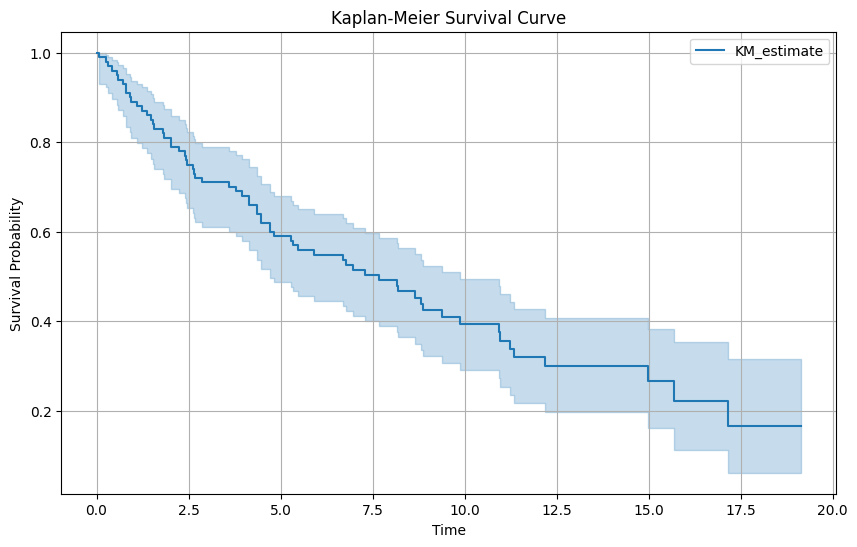

In [5]:
plt.figure(figsize=(10, 6))

kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")

plt.grid(True)
plt.show()

In [7]:
# assign groups
group = np.random.choice(["Control", "Treatment"], size=n)

true_time_adj = true_time.copy()

true_time_adj[group == "Treatment"] *= 1.3  # Treatment improves survival

time = np.minimum(true_time_adj, censor_time)
event = (true_time_adj <= censor_time).astype(int)

In [8]:
df = pd.DataFrame({
    "time": time,
    "event": event,
    "group": group
})

df.head()

,time,event,group
0,5.471438,0,Treatment
1,14.546156,0,Treatment
2,9.715340,0,Control
3,10.955311,1,Control
4,2.646148,1,Treatment


In [9]:
df.groupby("group")["event"].mean()

group
Control      0.711111
Treatment    0.545455
Name: event, dtype: float64

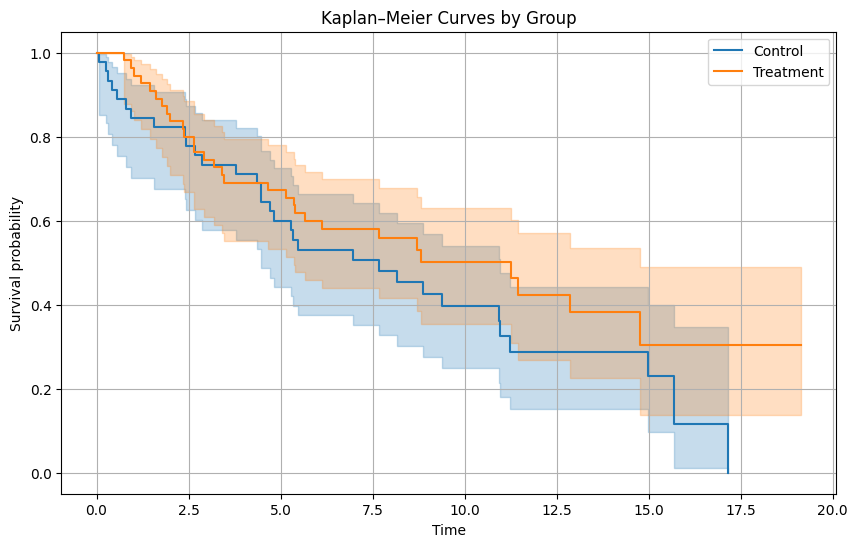

In [10]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(10,6))

for g in ["Control", "Treatment"]:
    kmf.fit(df[df["group"] == g]["time"],
            df[df["group"] == g]["event"],
            label=g)
    kmf.plot_survival_function()

plt.title("Kaplan–Meier Curves by Group")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

In [11]:
control = df[df["group"] == "Control"]
treatment = df[df["group"] == "Treatment"]

result = logrank_test(
    control["time"],
    treatment["time"],
    event_observed_A=control["event"],
    event_observed_B=treatment["event"]
)

result.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.82 0.18      2.50

### Interpretation of Results - evidence against $H_0$

A useful way to re-express p-values is through the transformation:

$$
-\log_2(p)
$$

This makes differences in small p-values easier to visualize.

| -log | p-value | Strength of evidence |
|----|----|----|
| 0 | 1.00 | None |
| 2 | 0.25 | Weak evidence |
| 3.3 | 0.10 | Mild evidence |
| 4.3 | 0.05 | Conventional significance threshold |
| 10+ | <0.01 | Very strong evidence |

- Larger values of $-\log_2(p)$ indicate stronger evidence against the null hypothesis.
- Values around 4.3 correspond to the classical 5% significance level.
- Very large values indicate extremely small p-values and strong evidence of an effect.

In this case, we fail to reject the null hypothesis.
> There is no statistically significant evidence that the two survival curves differ.


## 1. Survival Analysis Setup

In survival analysis, the response variable is a **time-to-event** outcome.

We observe:

- $T$: true event time (unknown for censored cases)
- $Y$: observed time
- $\delta$: event indicator

$$
Y = \min(T, C)
$$

$$
\delta =
\begin{cases}
1 & \text{if event observed (death/failure)} \\
0 & \text{if censored}
\end{cases}
$$

---
## 2. Censoring

Censoring occurs when the event is not fully observed.

In right censoring:

$$
T > Y
$$

We only know that survival exceeds the observed time.

---

## 3. Survival Function

The main object of interest is:

$$
S(t) = P(T > t)
$$

This represents the probability of surviving beyond time $t$.

---

## 4. Kaplan–Meier Estimator

The Kaplan–Meier estimator provides a non-parametric estimate of the survival function.

At each event time $t_i$:

- $n_i$: number at risk just before $t_i$
- $d_i$: number of events at $t_i$

The estimator is:

$$
\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)
$$

---
### Interpretation

- Survival decreases only at observed event times
- Censoring reduces the risk set but does not directly reduce survival
- The curve is a step function

---

## 5. Risk Set Intuition

At each time point:

- individuals still under observation form the risk set
- only those contribute to possible events

Censored observations:
- contribute information only up to censoring time
- then leave the risk set

---

## 6. Log-Rank Test: Motivation

After estimating survival curves, we often want to test:

> Do two groups have different survival experiences?

Examples:
- treatment vs control
- male vs female
- different medical procedures

---

We formalize:

$$
H_0: S_1(t) = S_2(t) \quad \forall t
$$

$$
H_1: S_1(t) \neq S_2(t) \ \text{for some } t
$$

---

## 7. Key Idea of Log-Rank Test

At each event time:

> Compare observed vs expected number of events under the assumption of equal survival.

Then aggregate across time.

---

## 8. Notation

At each event time $t_i$:

| Symbol | Meaning |
|--------|--------|
| $n_{1i}, n_{2i}$ | number at risk in each group |
| $d_{1i}, d_{2i}$ | observed deaths |
| $n_i$ | total at risk |
| $d_i$ | total deaths |

---

## 9. Expected Events Under $H_0$

Under equal survival, deaths are distributed proportionally:

$$
E_{1i} = d_i \cdot \frac{n_{1i}}{n_i}
$$

$$
E_{2i} = d_i \cdot \frac{n_{2i}}{n_i}
$$

Interpretation:

> expected deaths = risk-weighted allocation of observed events

---

## 10. Test Statistic

Define total observed and expected events:

$$
O_1 = \sum_i d_{1i}, \quad E_1 = \sum_i E_{1i}
$$

Then:

$$
Z = \frac{O_1 - E_1}{\sqrt{\mathrm{Var}(O_1 - E_1)}}
$$

---

### Null Distribution

Under $H_0$:

$$
Z \sim \mathcal{N}(0,1)
$$

Equivalently:

$$
Z^2 \sim \chi^2_1
$$

---

## 11. Interpretation

- If $O_1 > E_1$: group 1 has **better survival**
- If $O_1 < E_1$: group 1 has **worse survival**

Decision rule:

- small p-value → reject $H_0$
- large p-value → no evidence of difference

---

## 12. Relationship to Kaplan–Meier

| Method | Purpose |
|--------|--------|
| Kaplan–Meier | estimate survival curves |
| Log-Rank Test | compare survival curves statistically |